In [14]:
path = "first_scenario/"
import sys
import os
cwd = os.getcwd()
folder = os.path.dirname(cwd) 
sys.path.append(folder)
from utils_plot_python import *


C:\Users\csire\AppData\Local\anaconda3\envs\rstudio\lib\site-packages\pyvista\jupyter\notebook.py:59: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  f'Failed to use notebook backend: \n\n{e}\n\nFalling back to a static output.'


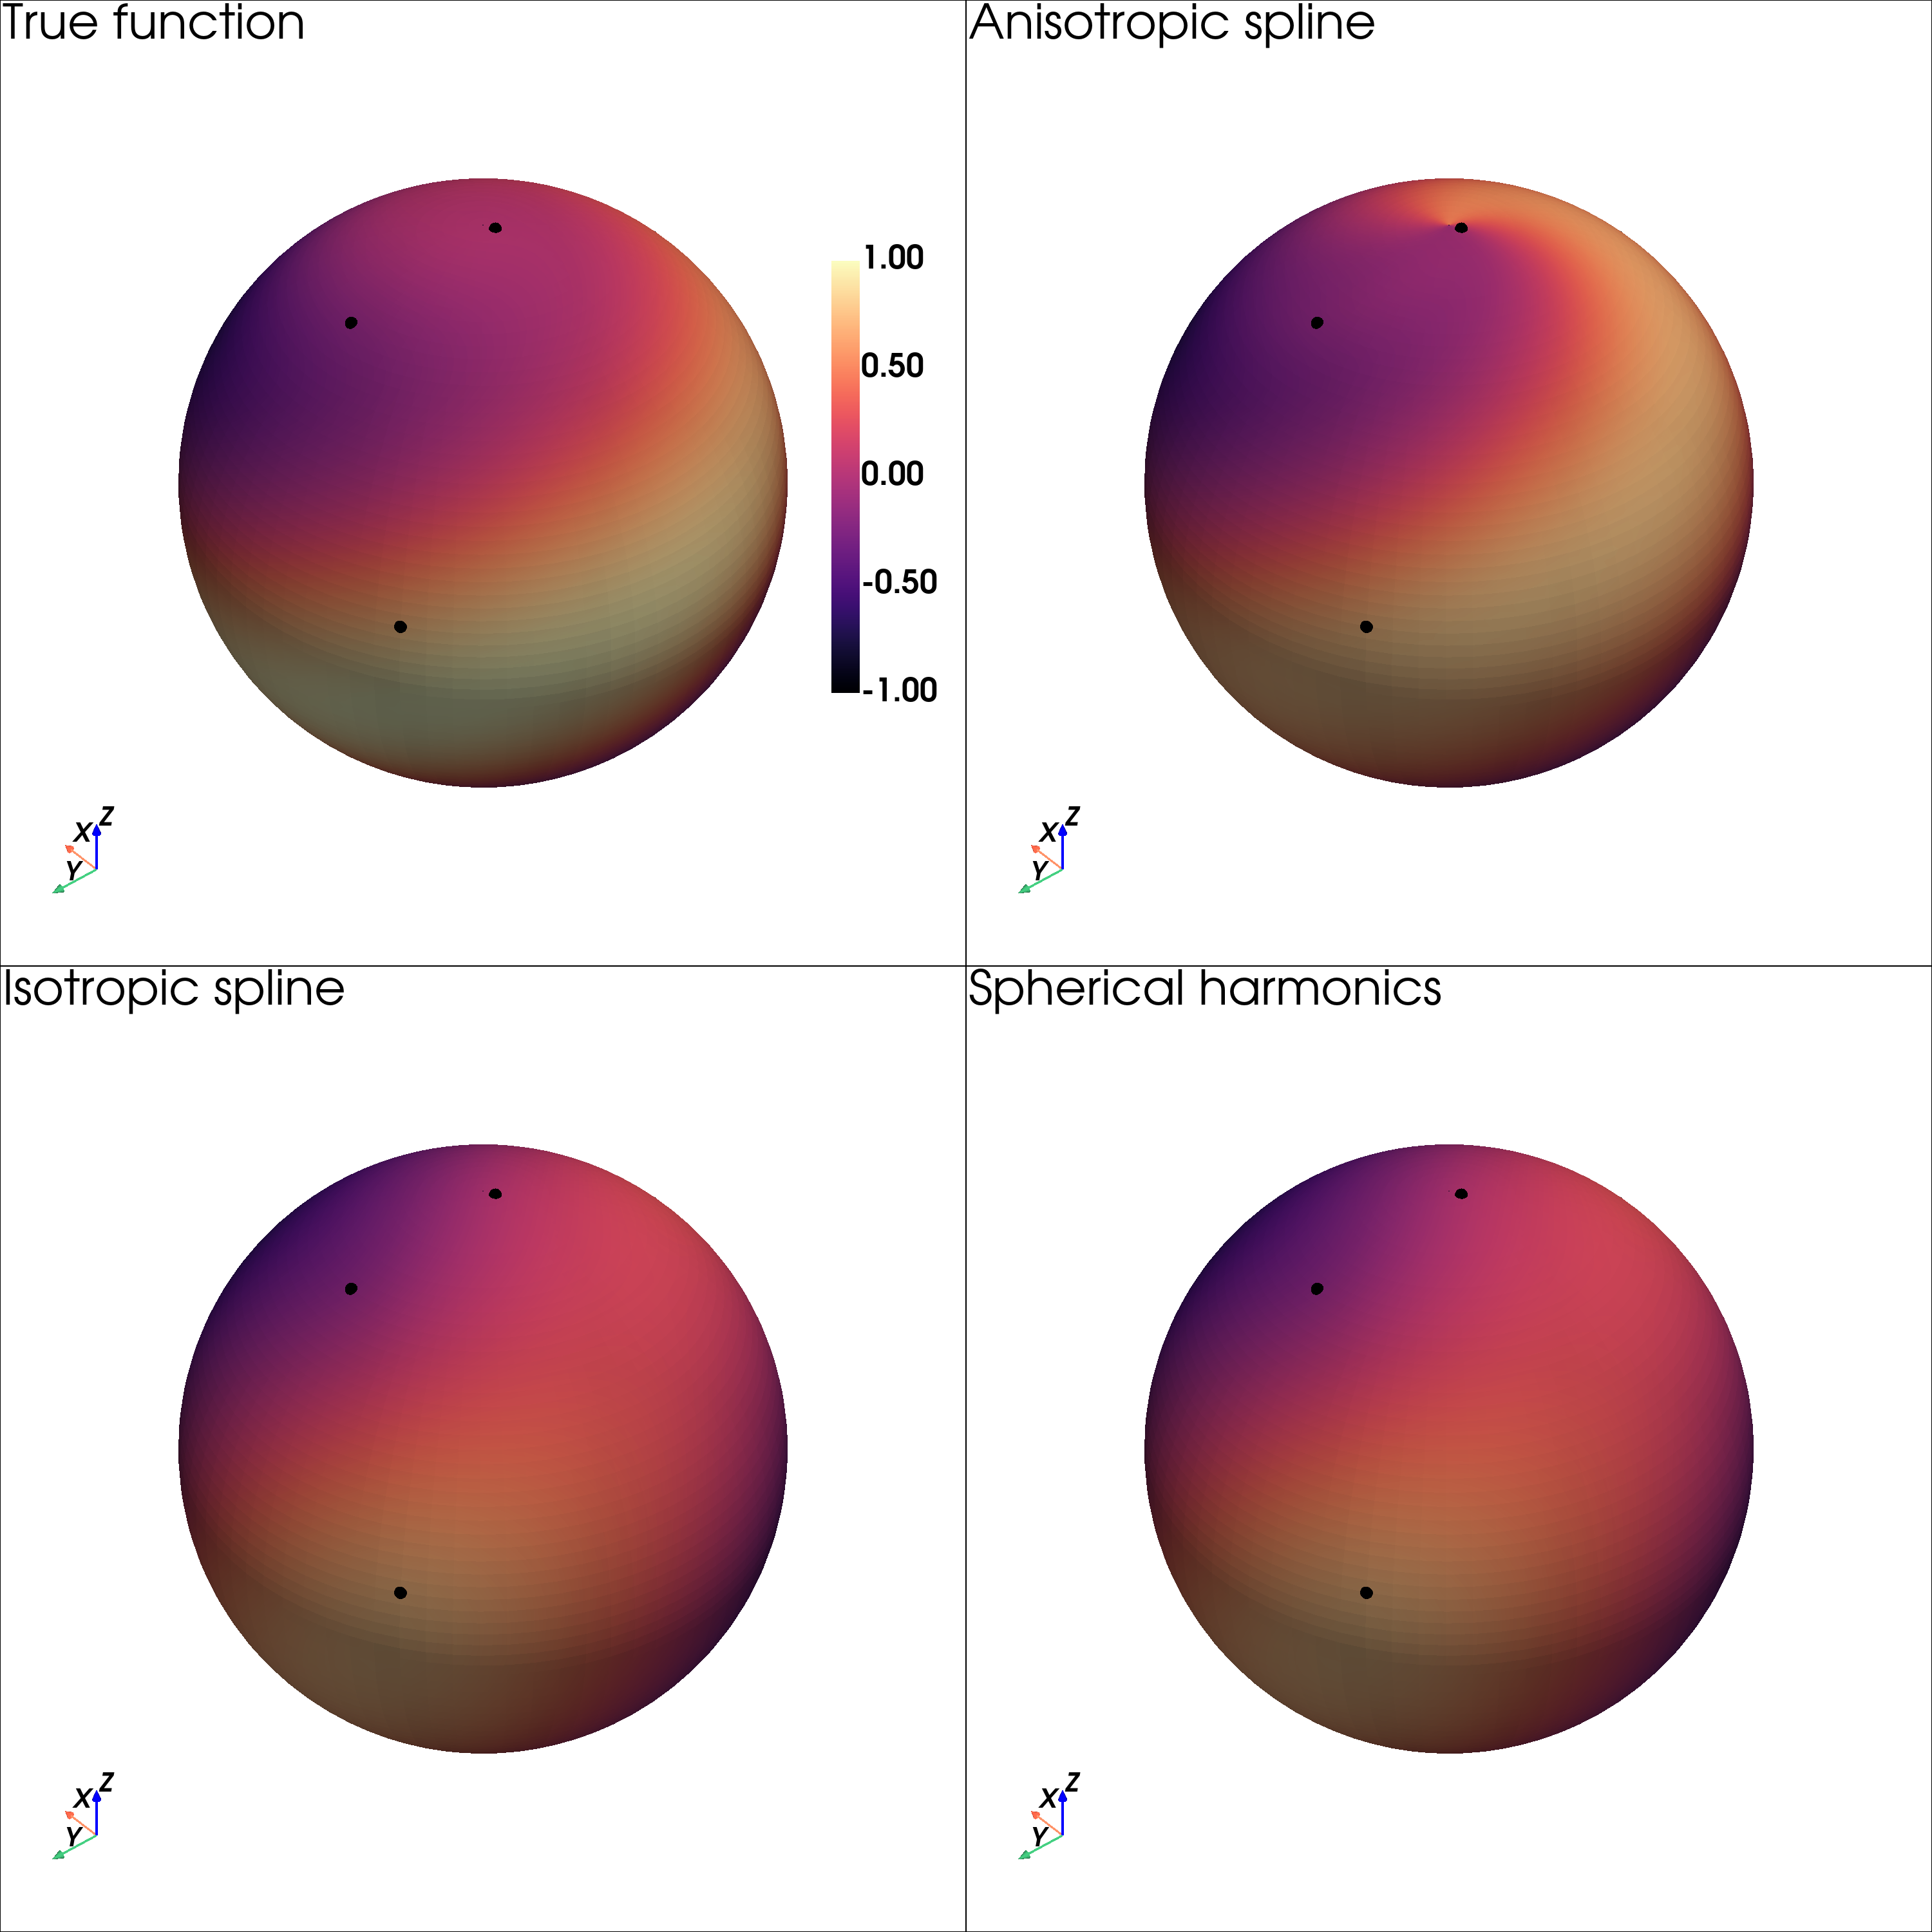

In [15]:
df_test = pd.read_csv(path+"df_test.csv")
df_pred_iso = pd.read_csv(path+"df_pred_iso.csv")
df_pred_harmo = pd.read_csv(path+"df_pred_harmo.csv")
df_pred_aniso = pd.read_csv(path+"df_pred_aniso.csv")
design = pd.read_csv(path+"design.csv")
#plot_sphere_3D([df_test.values,  df_pred_aniso.values, df_pred_iso.values, df_pred_harmo.values],  titles = ["True function", "Anisotropic spline", "Isotropic spline", "Spherical harmonics"], n_cols=2,n_rows=2, obs_points=design.values,obs_size = 18, distance = 6, elev =0, azim = 130, save = True, file_name = path+"plot_sphere.png",cmap = "magma")
plot_sphere_3D([df_test.values,  df_pred_aniso.values, df_pred_iso.values, df_pred_harmo.values],  titles = ["True function", "Anisotropic spline", "Isotropic spline", "Spherical harmonics"], n_cols=2,n_rows=2, obs_points=design.values,obs_size = 20, distance = 6, elev = 40, azim = 140, save = True, file_name = path+"plot_sphere.png",cmap = "magma")

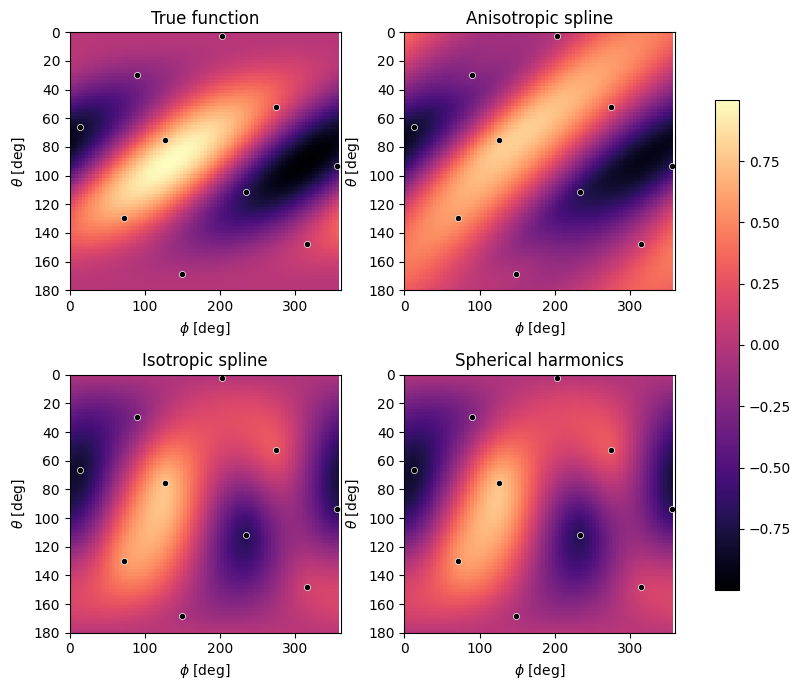

In [16]:
df_test = pd.read_csv(path+"df_test.csv")
df_pred_iso = pd.read_csv(path+"df_pred_iso.csv")
df_pred_harmo = pd.read_csv(path+"df_pred_harmo.csv")
df_pred_aniso = pd.read_csv(path+"df_pred_aniso.csv")
design = pd.read_csv(path+"design.csv")

plot_sphere_2D([df_test.values, df_pred_aniso.values, df_pred_iso.values, df_pred_harmo.values],  titles = ["True function", "Anisotropic spline", "Isotropic spline", "Spherical harmonics"], n_cols=2,n_rows=2, obs_points=design.values, save = True, file_name = path+"plot_sphere_2d.png", cmap= "magma")


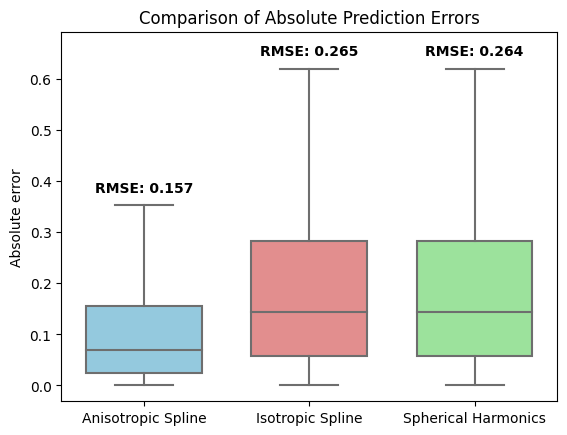

In [17]:
name_col = df_test.columns[2]

df_plot = pd.DataFrame({
    "Anisotropic Spline": abs(df_test[name_col] - df_pred_aniso[name_col]),
    "Isotropic Spline": abs(df_test[name_col] - df_pred_iso[name_col]),
    "Spherical Harmonics": abs(df_test[name_col] - df_pred_harmo[name_col])
})

# Melt for seaborn
df_melt = df_plot.melt(var_name="Model", value_name="Absolute error")

# Plot boxplot
sns.boxplot(
    data=df_melt,
    x="Model", y="Absolute error",
    palette=["skyblue", "lightcoral","lightgreen"],
    showfliers=False,
    width=0.7
)
plt.title("Comparison of Absolute Prediction Errors")
plt.xlabel("")

# Compute RMSE for each model
rmse_values = {col: np.sqrt(np.mean(df_plot[col]**2)) for col in df_plot.columns}

# Annotate RMSE above each top whisker (Q3 + 1.5*IQR) and track max label height
ax = plt.gca()
max_label = 0
for i, col in enumerate(df_plot.columns):
    q1 = np.percentile(df_plot[col], 25)
    q3 = np.percentile(df_plot[col], 75)
    iqr = q3 - q1
    whisker_top = q3 + 1.5 * iqr
    
    y_pos = whisker_top + 0.02
    max_label = max(max_label, y_pos)
    
    ax.text(
        i,
        y_pos,
        f"RMSE: {rmse_values[col]:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Extend y-axis slightly above the highest RMSE label
current_ylim = ax.get_ylim()
plt.ylim(current_ylim[0], max(max_label*1.08, current_ylim[1]))

plt.savefig(path + "boxplots_sphere.png", dpi=600, bbox_inches='tight')

plt.show()